<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/Midterm_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1A: Deal Size and Sales Cycle Trends

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the sales performance dataset and group the data by month

In [11]:

sales_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_sales_performance.csv')

# Preview dataset
sales_df.head()

,Deal_ID,Month,Region,Sales_Rep_ID,Deal_Size_USD,Sales_Cycle_Days,Monthly_Revenue_USD,Deal_Status
0,D-0001,1,West,REP-029,33854.81,46,34297.88,Won
1,D-0002,2,Central,REP-012,38628.50,55,35775.28,Won
2,D-0003,3,Central,REP-007,41541.02,40,43413.59,Won
3,D-0004,4,West,REP-029,26212.43,55,28067.30,Pending
4,D-0005,5,East,REP-011,30907.62,61,28738.42,Lost


### 2. Group Data by Month

In [4]:
monthly_stats = sales_df.groupby('Month').agg({
    'Deal_Size_USD': ['mean','median','std'],
    'Sales_Cycle_Days': ['mean','median','std']
}).reset_index()

monthly_stats

Month Deal_Size_USD                         Sales_Cycle_Days         \
                  mean     median          std             mean median   
0      1    38026.7636  37544.285  4605.335077            45.34   45.0   
1      2    37687.6206  38234.530  4887.820481            44.36   43.0   
2      3    37124.3256  37764.075  4254.276503            43.66   44.0   
3      4    37218.4746  37894.920  5348.472554            47.86   48.0   
4      5    35861.1158  35835.910  4658.321443            48.06   48.0   
5      6    36298.0538  36139.610  4450.532079            47.46   45.5   
6      7    37003.7090  37802.050  4723.241849            50.52   49.0   
7      8    34821.4040  34854.870  3972.269541            50.64   51.5   
8      9    35991.7680  36521.405  4006.273363            49.84   50.0   
9     10    34825.9896  35236.800  4672.314232            50.36   49.5   
10    11    34628.3982  34045.990  5258.896731            50.44   51.0   
11    12    34683.0312  34639.575  5404.933394            52.44   54.0   
12    13    32800.6996  32530.560  5217.312049            52.74   52.0   
13    14    32924.4004  33104.820  5182.082408            53.94   53.5   
14    15    32876.3770  33493.835  5051.955748            57.86   56.5   
15    16    32015.4978  31641.100  5558.337450            54.46   54.5   
16    17    31549.9096  32132.605  4481.490738            55.88   57.0   
17    18    32508.4056  32456.855  5134.310739            58.08   57.5   
18    19    31210.4926  31057.200  4875.856109            59.48   60.0   
19    20    28612.1666  27653.590  4870.947990            60.98   62.0   
20    21    31856.3216  31735.590  5145.180628            58.90   60.0   
21    22    30483.8518  30900.945  5226.775692            59.60   60.0   
22    23    28758.5224  27901.905  5237.298287            61.38   61.0   
23    24    29788.6270  29901.060  4840.516929            61.80   62.0   

              
         std  
0   8.721566  
1   7.718940  
2   7.646821  
3   7.876625  
4   7.072251  
5   8.376863  
6   8.194672  
7   9.635733  
8   7.581826  
9   6.090340  
10  8.418056  
11  7.910623  
12  8.451084  
13  8.862694  
14  6.527837  
15  9.089599  
16  8.006732  
17  8.639822  
18  7.772899  
19  7.825886  
20  8.381832  
21  7.801099  
22  7.024418  
23  7.858441

### Flatten Column Names (easier to use)

In [5]:
monthly_stats.columns = [
    'Month',
    'Deal_Size_Mean',
    'Deal_Size_Median',
    'Deal_Size_STD',
    'Sales_Cycle_Mean',
    'Sales_Cycle_Median',
    'Sales_Cycle_STD'
]

monthly_stats

,Month,Deal_Size_Mean,Deal_Size_Median,Deal_Size_STD,Sales_Cycle_Mean,Sales_Cycle_Median,Sales_Cycle_STD
0,1,38026.7636,37544.285,4605.335077,45.34,45.0,8.721566
1,2,37687.6206,38234.530,4887.820481,44.36,43.0,7.718940
2,3,37124.3256,37764.075,4254.276503,43.66,44.0,7.646821
3,4,37218.4746,37894.920,5348.472554,47.86,48.0,7.876625
4,5,35861.1158,35835.910,4658.321443,48.06,48.0,7.072251
5,6,36298.0538,36139.610,4450.532079,47.46,45.5,8.376863
6,7,37003.7090,37802.050,4723.241849,50.52,49.0,8.194672
7,8,34821.4040,34854.870,3972.269541,50.64,51.5,9.635733
8,9,35991.7680,36521.405,4006.273363,49.84,50.0,7.581826
9,10,34825.9896,35236.800,4672.314232,50.36,49.5,6.090340


### 3. Create line charts showing the month-over-month trend for both variables

#### Plot Trend for Deal Size

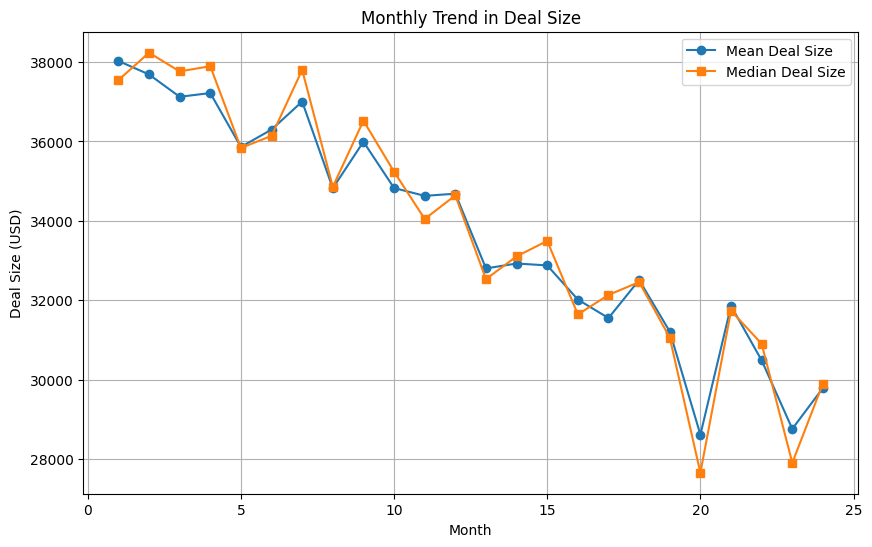

In [6]:
plt.figure(figsize=(10,6))

plt.plot(monthly_stats['Month'], monthly_stats['Deal_Size_Mean'], marker='o', label='Mean Deal Size')
plt.plot(monthly_stats['Month'], monthly_stats['Deal_Size_Median'], marker='s', label='Median Deal Size')

plt.title('Monthly Trend in Deal Size')
plt.xlabel('Month')
plt.ylabel('Deal Size (USD)')
plt.legend()
plt.grid(True)

plt.show()

#### Plot Trend for Sales Cycle

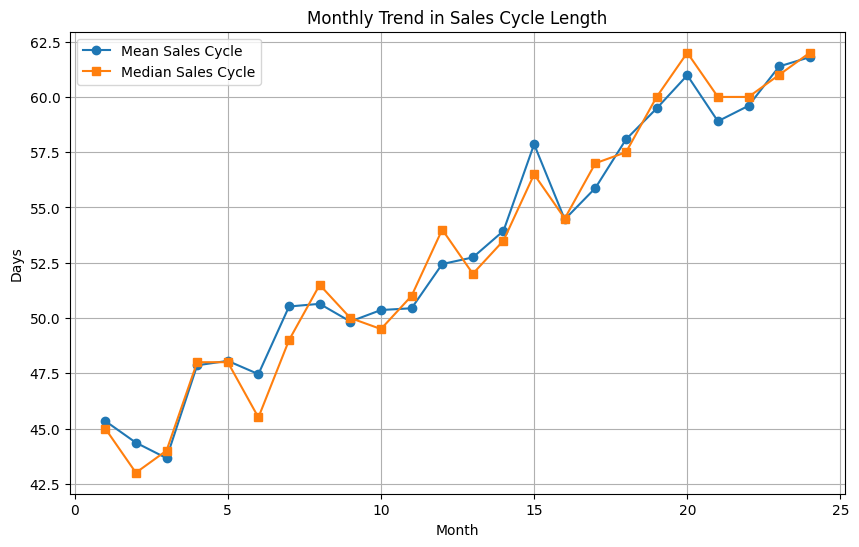

In [7]:
plt.figure(figsize=(10,6))

plt.plot(monthly_stats['Month'], monthly_stats['Sales_Cycle_Mean'], marker='o', label='Mean Sales Cycle')
plt.plot(monthly_stats['Month'], monthly_stats['Sales_Cycle_Median'], marker='s', label='Median Sales Cycle')

plt.title('Monthly Trend in Sales Cycle Length')
plt.xlabel('Month')
plt.ylabel('Days')
plt.legend()
plt.grid(True)

plt.show()

#### Combined Trend Chart (Often Required)

<Figure size 1000x600 with 0 Axes>

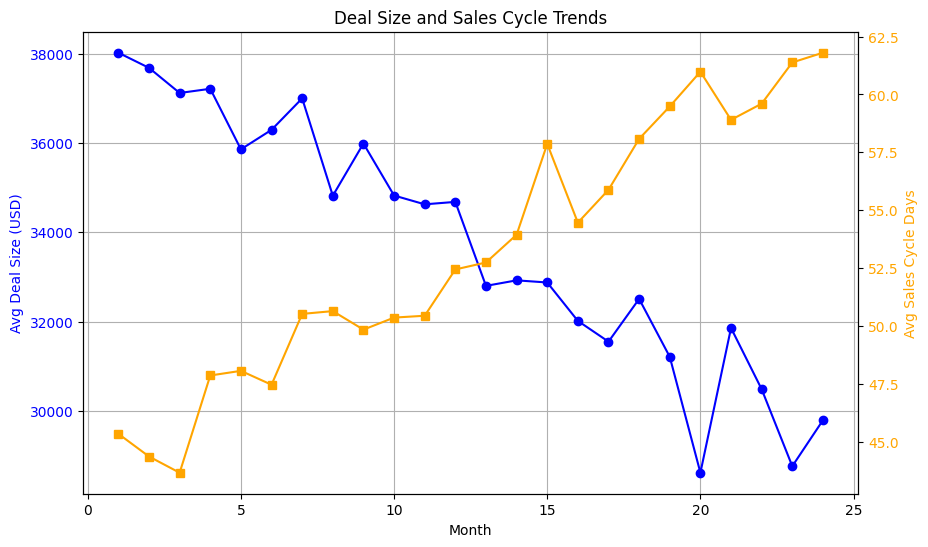

In [8]:
plt.figure(figsize=(10,6))

fig, ax1 = plt.subplots(figsize=(10,6))

# Primary axis (Deal Size)
ax1.plot(monthly_stats['Month'],
         monthly_stats['Deal_Size_Mean'],
         marker='o',
         color='blue',
         label='Avg Deal Size')

ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Deal Size (USD)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary axis (Sales Cycle)
ax2 = ax1.twinx()

ax2.plot(monthly_stats['Month'],
         monthly_stats['Sales_Cycle_Mean'],
         marker='s',
         color='orange',
         label='Avg Sales Cycle Days')

ax2.set_ylabel('Avg Sales Cycle Days', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and grid
plt.title('Deal Size and Sales Cycle Trends')
ax1.grid(True)

plt.show()

## Markdown Narrative Interpretation

Over the 24-month period, the average and median deal sizes show a gradual downward trend, declining from roughly $38,000 early in the timeline to around $30,000 by the end. This suggests that the organization may be closing smaller deals over time, potentially reflecting increased competition, a shift toward lower-value clients, or a strategic focus on higher deal volume rather than larger contracts. The close alignment between the mean and median indicates that the distribution of deal sizes is relatively balanced without extreme outliers significantly affecting the averages.

At the same time, the sales cycle length shows a steady upward trend, increasing from approximately 44–46 days in the early months to about 60–62 days toward the end of the period. This indicates that it is taking longer for the sales team to close deals, which may reflect increased complexity in negotiations, more rigorous customer evaluation processes, or greater competition in the marketplace.

Together, these trends suggest that NovaTech’s sales pipeline may be experiencing declining efficiency. Smaller deals combined with longer sales cycles can reduce overall revenue growth and slow the velocity of the sales pipeline. For leadership, this may signal a need to evaluate sales strategies, reassess customer targeting, or streamline the sales process to maintain a healthy and productive pipeline.


Deal Size Summary:
count     1200.000000
mean     33731.496917
std       5595.821662
min      15541.950000
25%      30084.165000
50%      33847.580000
75%      37763.597500
max      49121.980000
Name: Deal_Size_USD, dtype: float64

Sales Cycle Length Summary:
count    1200.000000
mean       53.170000
std         9.666642
min        22.000000
25%        46.000000
50%        54.000000
75%        60.000000
max        81.000000
Name: Sales_Cycle_Days, dtype: float64
    Month  avg_deal_size  median_deal_size  avg_cycle_length  deal_count
0       1     38026.7636         37544.285             45.34          50
1       2     37687.6206         38234.530             44.36          50
2       3     37124.3256         37764.075             43.66          50
3       4     37218.4746         37894.920             47.86          50
4       5     35861.1158         35835.910             48.06          50
5       6     36298.0538         36139.610             47.46          50
6       7     37003.70

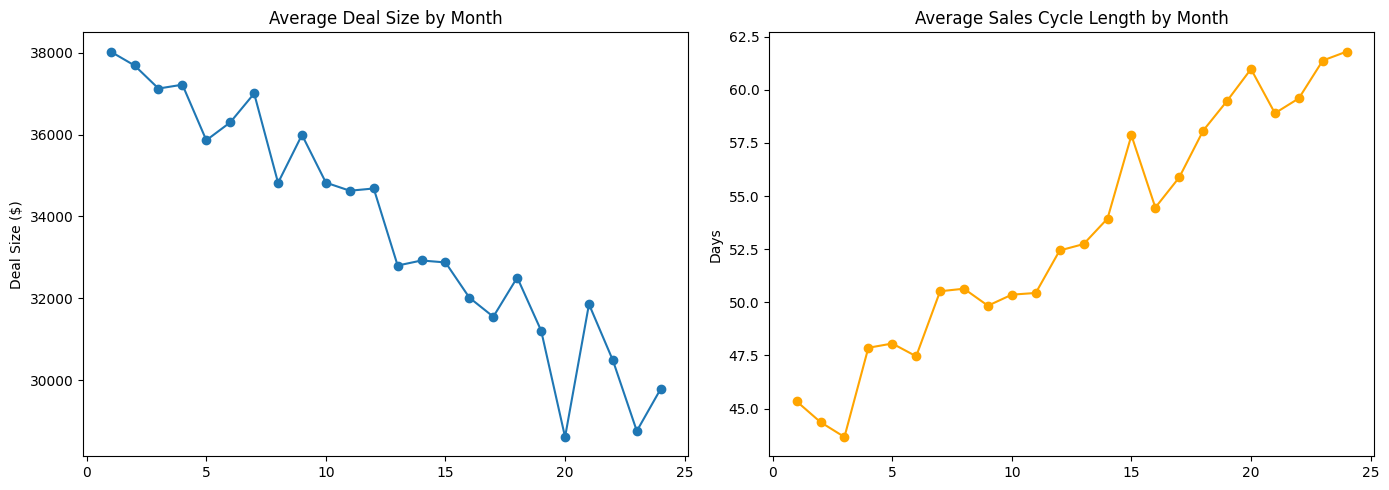

In [10]:
# Step 1: Descriptive statistics

print("Deal Size Summary:")
print(sales_df['Deal_Size_USD'].describe())

print("\nSales Cycle Length Summary:")
print(sales_df['Sales_Cycle_Days'].describe())

monthly = sales_df.groupby('Month').agg(
    avg_deal_size=('Deal_Size_USD','mean'),
    median_deal_size=('Deal_Size_USD','median'),
    avg_cycle_length=('Sales_Cycle_Days','mean'),
    deal_count=('Deal_Size_USD','count')
).reset_index()

print(monthly)

fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(monthly['Month'], monthly['avg_deal_size'], marker='o')
axes[0].set_title('Average Deal Size by Month')
axes[0].set_ylabel('Deal Size ($)')

axes[1].plot(monthly['Month'], monthly['avg_cycle_length'], marker='o', color='orange')
axes[1].set_title('Average Sales Cycle Length by Month')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.show()

## Interpretation: Cost Per Lead (CPL) by Marketing Channel

The chart compares the **cost per lead across NovaTech’s marketing channels** and highlights the **average CPL (≈ $36)** with a dashed red line. Digital Paid advertising has the highest CPL at roughly **$59**, significantly above the average. This suggests that paid digital campaigns are currently the least cost-efficient channel, possibly due to high bidding competition, audience saturation, or inefficient targeting strategies.

In contrast, **Content Marketing, SEO, Email, and Social Media** generate leads at a cost **below the overall average**, making them more efficient channels for customer acquisition. Content Marketing and SEO, in particular, show the lowest CPL values, indicating that organic or inbound marketing strategies are producing leads at a relatively low cost.

Events and Social Media fall near the middle range, slightly below the average CPL, suggesting moderate efficiency compared to other channels. Overall, the results imply that NovaTech should **re-evaluate its Digital Paid strategy** while potentially allocating more resources to **Content Marketing, SEO, and Email**, which appear to generate leads more cost-effectively.


## 1b-Marketing Diminishing Returns

**Goal:** Identify which channels are underperforming despite increased digital spend

### 1. Load the Marketing Campaign Dataset and Explore Structure

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
campaigns_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_marketing_campaigns.csv')

# Preview dataset
campaigns_df.head()

# Inspect structure
campaigns_df.info()

# Summary statistics
campaigns_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Campaign_ID        48 non-null     object 
 1   Month              48 non-null     int64  
 2   Channel            48 non-null     object 
 3   Spend_USD          48 non-null     float64
 4   Leads_Generated    48 non-null     int64  
 5   Conversion_Rate    48 non-null     float64
 6   Cost_Per_Lead_USD  48 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 2.8+ KB


,Month,Spend_USD,Leads_Generated,Conversion_Rate,Cost_Per_Lead_USD
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,12.500000,16457.536458,426.854167,0.070788,37.793958
std,6.995439,13832.299448,270.076111,0.025637,14.994093
min,1.000000,2849.130000,89.000000,0.021500,16.170000
25%,6.750000,7529.115000,237.250000,0.058175,26.705000
50%,12.500000,11158.910000,382.500000,0.068250,36.030000
75%,18.250000,17558.052500,491.750000,0.091400,46.550000
max,24.000000,58273.410000,1336.000000,0.118400,78.000000


### 2. Calculate Cost Per Lead (CPL)

In [22]:
campaigns_df['Leads_Per_Dollar'] = campaigns_df['Leads_Generated'] / campaigns_df['Spend_USD']

### 3. Channel Performance Summary Table

In [23]:
channel_summary = campaigns_df.groupby('Channel').agg(
    Total_Spend=('Spend_USD','sum'),
    Total_Leads=('Leads_Generated','sum'),
    Avg_CPL=('Cost_Per_Lead_USD','mean'),
    Avg_Conversion_Rate=('Conversion_Rate','mean'),
    Leads_Per_Dollar=('Leads_Per_Dollar','mean')
).reset_index()

channel_summary

,Channel,Total_Spend,Total_Leads,Avg_CPL,Avg_Conversion_Rate,Leads_Per_Dollar
0,Content_Marketing,83568.30,2935,31.31750,0.068450,0.037251
1,Digital_Paid,321506.26,5415,62.25000,0.079800,0.016512
2,Email,49597.83,1575,33.34000,0.071362,0.033471
3,Events,175499.26,5149,36.77750,0.070038,0.029261
4,SEO,91529.56,3170,29.09375,0.067913,0.035313
5,Social_Media,68260.54,2245,33.98500,0.067162,0.033471


### 4. Bar Chart — Cost Per Lead by Channel

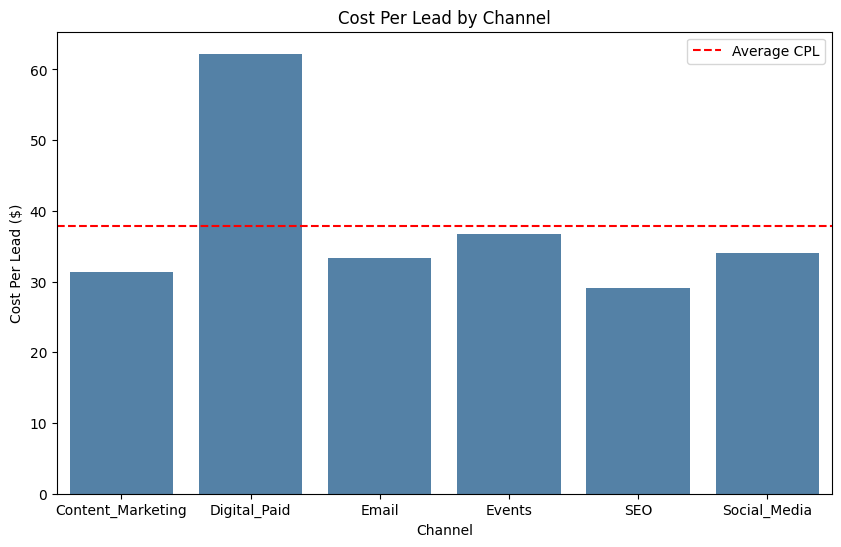

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=channel_summary,
    x='Channel',
    y='Avg_CPL',
    color='steelblue'
)

plt.axhline(channel_summary['Avg_CPL'].mean(),
            color='red',
            linestyle='--',
            label='Average CPL')

plt.title('Cost Per Lead by Channel')
plt.ylabel('Cost Per Lead ($)')
plt.xlabel('Channel')
plt.legend()

plt.show()

### 5. Digital Paid CPL Trend Over Time

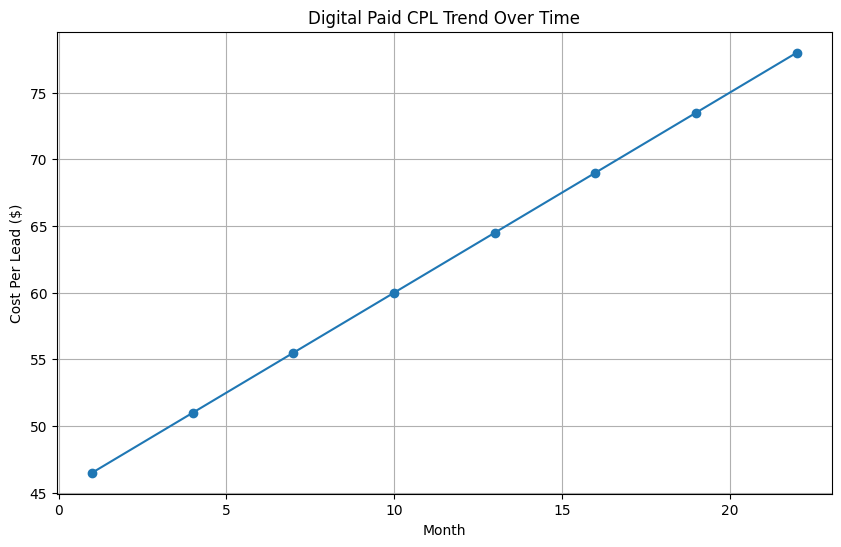

In [25]:
digital_paid = campaigns_df[campaigns_df['Channel'] == 'Digital_Paid']

digital_trend = digital_paid.groupby('Month')['Cost_Per_Lead_USD'].mean().reset_index()

plt.figure(figsize=(10,6))

plt.plot(digital_trend['Month'],
         digital_trend['Cost_Per_Lead_USD'],
         marker='o')

plt.title('Digital Paid CPL Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Cost Per Lead ($)')
plt.grid(True)

plt.show()

### 6. Year 1 vs Year 2 Comparison

In [26]:
digital_paid['Year'] = np.where(digital_paid['Month'] <= 12, 'Year 1', 'Year 2')

year_comparison = digital_paid.groupby('Year').agg(
    Total_Spend=('Spend_USD','sum'),
    Avg_CPL=('Cost_Per_Lead_USD','mean')
).reset_index()

year_comparison

/tmp/ipykernel_779/939821071.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  digital_paid['Year'] = np.where(digital_paid['Month'] <= 12, 'Year 1', 'Year 2')


,Year,Total_Spend,Avg_CPL
0,Year 1,173590.65,53.25
1,Year 2,147915.61,71.25


### 7. Visualization: Year Comparison

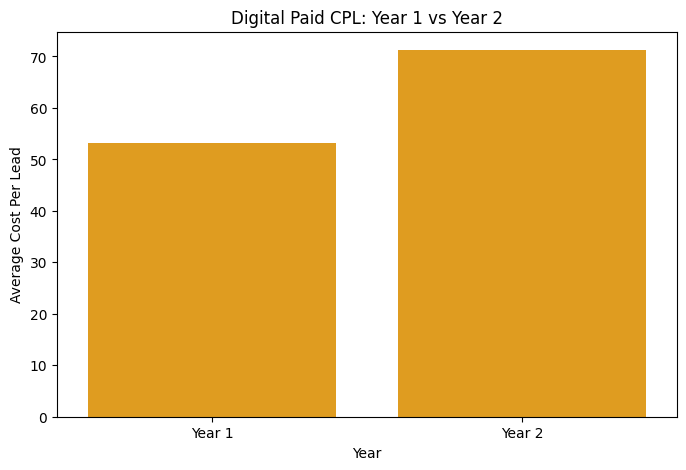

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=year_comparison,
    x='Year',
    y='Avg_CPL',
    color='orange'
)

plt.title('Digital Paid CPL: Year 1 vs Year 2')
plt.ylabel('Average Cost Per Lead')

plt.show()

## Marketing Campaign Performance Analysis

The analysis shows that marketing performance varies across channels in both efficiency and cost. Digital Paid has the highest average cost per lead (about $62), significantly above the overall average CPL of roughly $38. Despite generating the largest number of total leads (5,415), it requires substantially higher spending to acquire each lead, indicating lower cost efficiency compared with other channels. In contrast, channels such as SEO, Content Marketing, and Email produce leads at a much lower cost per lead and generate more leads per dollar spent, making them more efficient acquisition channels.

Over time, the Digital Paid cost per lead shows a clear upward trend, increasing steadily from the mid-$40 range in early months to nearly $80 by the end of the period. This pattern indicates diminishing returns, where additional advertising spend results in progressively higher acquisition costs. The Year-1 versus Year-2 comparison confirms this trend: the average CPL increased from about $53.25 in Year 1 to $71.25 in Year 2, even though total spending decreased. This suggests the advertising channel is becoming less efficient over time.

Overall, the evidence indicates that Digital Paid is the primary underperforming channel due to its rising CPL and declining efficiency. While it still generates a high volume of leads, the increasing cost suggests audience saturation, greater bidding competition, or less effective targeting. In contrast, channels like SEO, Content Marketing, and Email appear to deliver more cost-efficient results and may represent better opportunities for future marketing investment.


## 1C-Churned vs. Retained Custromer Profile

**Goal:** Build a descriptive comparison using means, medians, and standard deviations.

### Step 1 — Load the Customer Accounts Dataset

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_customer_accounts.csv')

customers_df.head()

,Account_ID,Contract_Value_USD,Tenure_Months,Support_Tickets_12Mo,Satisfaction_Score,Churn_Status
0,A-0001,106091.11,51,3,7.1,Retained
1,A-0002,46231.59,55,4,7.2,Retained
2,A-0003,74657.49,44,8,4.7,Churned
3,A-0004,103202.64,65,4,6.7,Retained
4,A-0005,58540.18,25,4,6.6,Retained


### Step 2 — Split into Churned and Retained Customers

In [29]:
churned = customers_df[customers_df['Churn_Status'] == 'Churned']
retained = customers_df[customers_df['Churn_Status'] == 'Retained']

### Step 3 — Compute Descriptive Statistics

In [30]:
metrics = ['Contract_Value_USD', 'Tenure_Months', 'Satisfaction_Score']

profile = pd.DataFrame()

for m in metrics:
    profile.loc[m, 'Churned_Mean'] = churned[m].mean()
    profile.loc[m, 'Retained_Mean'] = retained[m].mean()
    profile.loc[m, 'Churned_Median'] = churned[m].median()
    profile.loc[m, 'Retained_Median'] = retained[m].median()
    profile.loc[m, 'Churned_Std'] = churned[m].std()
    profile.loc[m, 'Retained_Std'] = retained[m].std()

print(profile.round(2))

                    Churned_Mean  Retained_Mean  Churned_Median  \
Contract_Value_USD      63163.72       64794.23        61453.41   
Tenure_Months              35.07          38.24           34.00   
Satisfaction_Score          5.06           7.05            5.20   

                    Retained_Median  Churned_Std  Retained_Std  
Contract_Value_USD         61783.86     32099.07      30385.65  
Tenure_Months                 39.00        21.60         21.03  
Satisfaction_Score             7.00         1.15          0.98  


### Step 4 — Create Difference Table

In [31]:
difference_table = pd.DataFrame({
    'Metric': metrics,
    'Mean_Difference': [
        retained[m].mean() - churned[m].mean() for m in metrics
    ],
    'Median_Difference': [
        retained[m].median() - churned[m].median() for m in metrics
    ]
})

difference_table

,Metric,Mean_Difference,Median_Difference
0,Contract_Value_USD,1630.506596,330.45
1,Tenure_Months,3.176163,5.00
2,Satisfaction_Score,1.989370,1.80


### Step 5 — Calculate Overall Churn Rate

In [32]:
churn_rate = (customers_df['Churn_Status'] == 'Churned').mean()

print("Overall Churn Rate:", round(churn_rate * 100, 2), "%")

Overall Churn Rate: 46.9 %


### Step 6 — Create Side-by-Side Boxplots

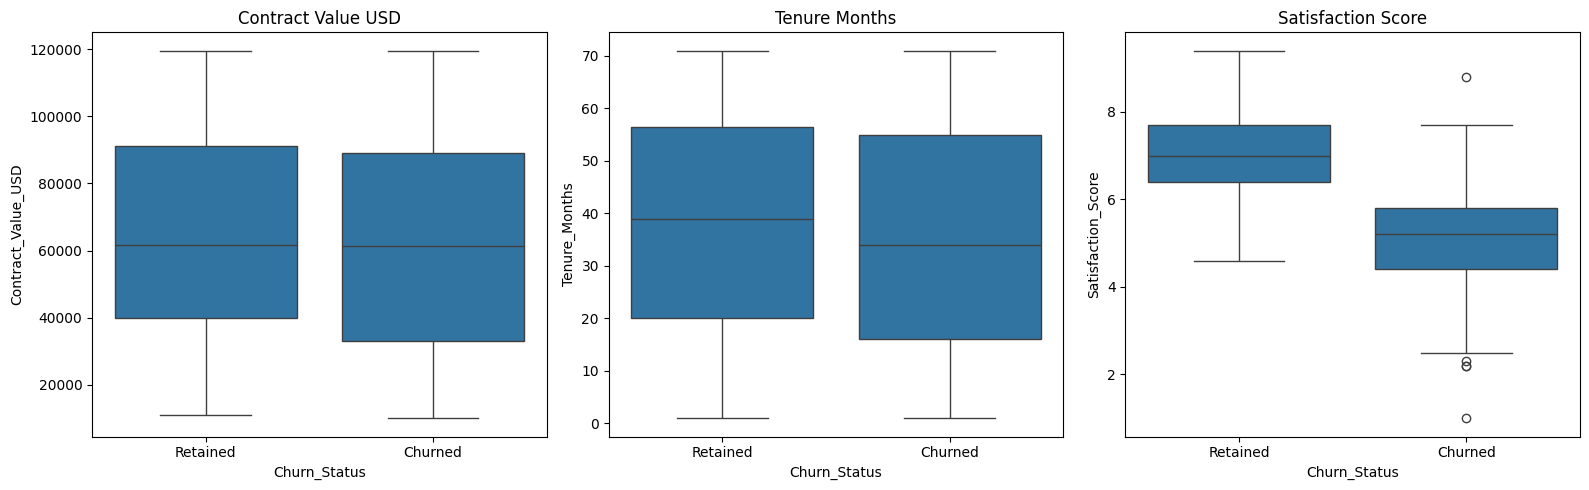

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for i, m in enumerate(metrics):

    sns.boxplot(
        x='Churn_Status',
        y=m,
        data=customers_df,
        ax=axes[i]
    )

    axes[i].set_title(m.replace('_',' '))

plt.tight_layout()

plt.savefig('churn_profile_boxplots.png', dpi=150)

plt.show()

## Written Narrative

The statistical profile shows clear differences between churned and retained customers across contract value, tenure, and satisfaction scores. Retained customers have slightly higher average contract values (about 64,794 dollars vs. 63,164 dollars) and longer average tenure (38.24 months vs. 35.07 months), indicating that longer relationships are associated with higher retention. The most significant distinction appears in customer satisfaction, where retained customers have an average score of 7.05 compared with 5.06 for churned customers. This large gap suggests that lower satisfaction levels are strongly associated with customer churn. Overall, customers who churn tend to have lower satisfaction and slightly shorter tenures, indicating that improving customer experience and engagement early in the relationship could help reduce churn.

## Customer Churn Profile Interpretation

The comparison between churned and retained customers reveals several meaningful differences in customer behavior and satisfaction. Retained customers have slightly higher average contract values (about 64,794 dollars vs. 63,164 dollars) and notably longer tenure, averaging roughly **38 months compared to 35 months for churned customers**. This suggests that customers who remain with the company tend to maintain longer relationships and slightly higher-value contracts.

The most significant distinction appears in **customer satisfaction scores**. Retained customers report an average satisfaction score of **about 7.05**, while churned customers average **around 5.06**, indicating a substantial gap in perceived service quality. The box plots also show that churned customers cluster around lower satisfaction levels and exhibit greater variability.

Overall, the analysis suggests that **customer satisfaction is the strongest indicator of churn**, followed by tenure length. Customers with lower satisfaction and shorter relationships are more likely to leave, indicating that improving customer experience and engagement early in the lifecycle may significantly reduce churn rates.
